<a href="https://colab.research.google.com/github/bhuvighosh3/Forecasting-project/blob/main/Electricity_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [52]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats

In [53]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Cleaning:

We load the electricity consumption dataset (15-minute resolution) and:

- Parse timestamps.
- Set datetime index.
- Sort chronologically.
- Handle missing values.
- Remove rows where all clients have zero consumption.

In [ ]:
df = pd.read_csv(
    '/content/LD2011_2014.txt',
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

df.iloc[:,0] = pd.to_datetime(df.iloc[:,0])  # convert first column
df = df.set_index(df.columns[0])

print(df.index[:5])

In [ ]:
df.head()

In [ ]:
df = df.sort_index()

In [ ]:
print("Total missing:", df.isna().sum().sum())

In [ ]:
df = df.fillna(method='ffill')

In [ ]:
print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())
print("Zero rows (all clients zero):", (df == 0).all(axis=1).sum())

In [ ]:
df = df[(df != 0).any(axis=1)]
print("Shape after dropping all-zero rows:", df.shape)

## 2. Cross-Client Correlation Analysis:

We compute the correlation matrix between all clients and visualize it using a heatmap.  
We also examine highly correlated client pairs (r > 0.85).

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False)
plt.title("Cross-Client Correlation Heatmap")
plt.tight_layout()
plt.show()

In [38]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
flat_corr = upper_tri.stack()
print("\nCorrelation stats across all client pairs:")
print(flat_corr.describe())


Correlation stats across all client pairs:
count    17955.000000
mean         0.560651
std          0.317962
min         -0.793729
25%          0.332929
50%          0.718748
75%          0.834730
max          0.976927
dtype: float64


In [39]:
high_corr = flat_corr[flat_corr > 0.85]
print(f"\nPairs with r > 0.85: {len(high_corr)}")
print(high_corr.sort_values(ascending=False).head(20))


Pairs with r > 0.85: 3202
0.24  0.25    0.976927
0.7   0.8     0.969432
0.20  0.36    0.961473
      0.24    0.959593
      0.34    0.956956
0.2   0.4     0.956185
0.19  0.20    0.951114
0.34  0.39    0.950118
0.18  0.37    0.949905
0.19  0.36    0.949737
      0.34    0.948678
0.20  0.25    0.948632
0.18  0.34    0.948597
0.34  0.36    0.947673
0.21  0.34    0.943546
      0.36    0.942281
0.24  0.34    0.940158
0.19  0.39    0.938659
0.25  0.34    0.938640
0.18  0.39    0.938517
dtype: float64


In [40]:
scaler = StandardScaler()
# Transpose: each client is a sample, each timestep is a feature
X = scaler.fit_transform(df.T)  # shape: (n_clients, n_timesteps)

## 3. PCA for Dimensionality Reduction and KMeans Clustering

Steps:
1. Standardize each client time series.
2. Apply PCA (10 components).
3. Use the Elbow Method to select the number of clusters.
4. Apply KMeans clustering.

In [41]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)
print(f"\nPCA explained variance (10 components): {pca.explained_variance_ratio_.sum():.2%}")


PCA explained variance (10 components): 99.90%


## 4. Build Cluster-Level Mean Series

For each cluster:
- Compute mean consumption across members.
- Store cleaned mean time series.

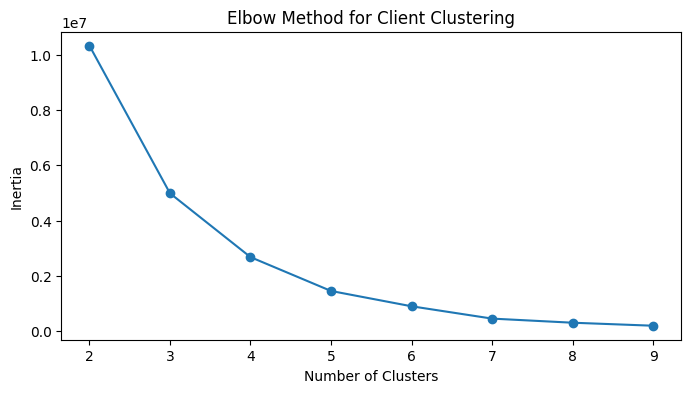

In [42]:
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Client Clustering")
plt.show()

In [43]:
K_BEST = 6
km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
labels = km.fit_predict(X_pca)
client_clusters = pd.Series(labels, index=df.columns, name='cluster')
print("\nClients per cluster:\n", client_clusters.value_counts())


Clients per cluster:
 cluster
0    176
5     10
4      1
2      1
1      1
3      1
Name: count, dtype: int64


In [44]:
df['global_mean'] = df.drop(columns='global_mean', errors='ignore').mean(axis=1)

cluster_means = {}
for c in range(K_BEST):
    members = client_clusters[client_clusters == c].index.tolist()
    cluster_means[f'cluster_{c}_mean'] = df[members].mean(axis=1)

cluster_df = pd.DataFrame(cluster_means, index=df.index)
cluster_df['global_mean'] = df['global_mean']

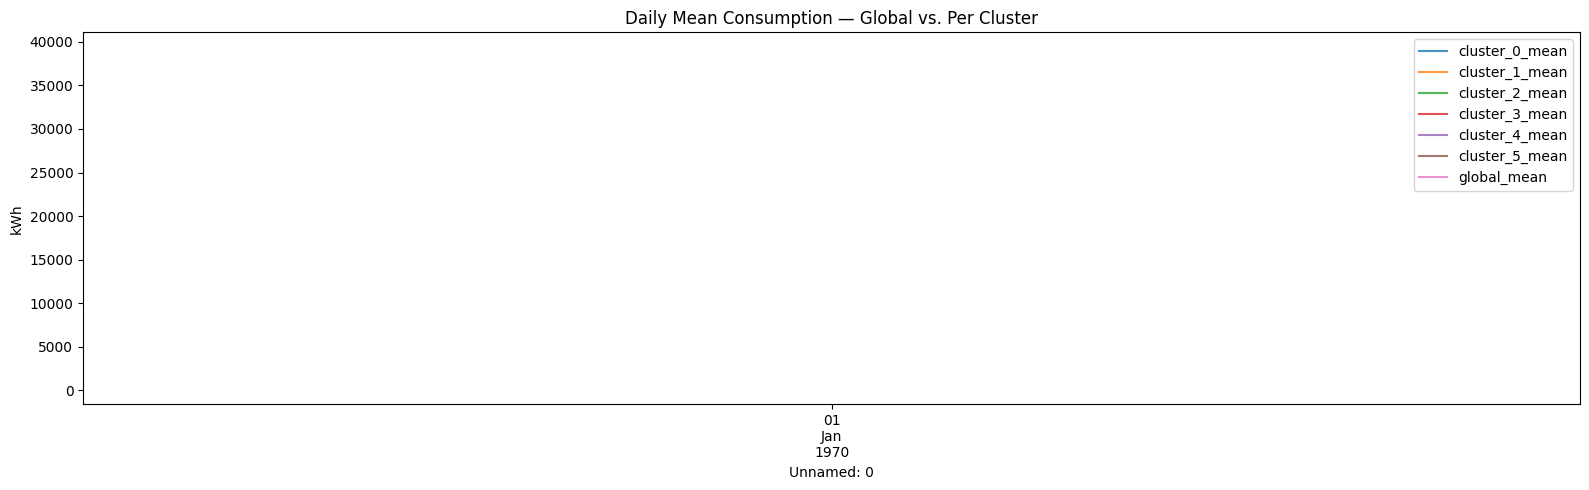

In [20]:
cluster_df.resample('D').mean().plot(figsize=(16, 5), alpha=0.8)
plt.title("Daily Mean Consumption — Global vs. Per Cluster")
plt.ylabel("kWh")
plt.tight_layout()
plt.show()


PCA explained variance (10 components): 99.90%


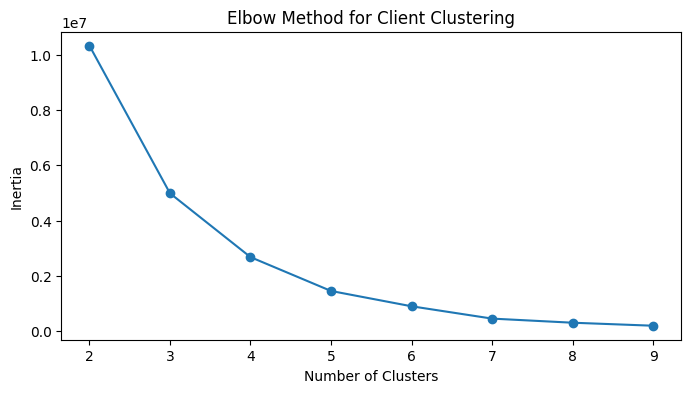


Clients per cluster:
 cluster
0    176
5     10
4      1
2      1
1      1
3      1
Name: count, dtype: int64

Cluster series built:
  Cluster 0: 176 clients | series length: 134718 | mean value: 334.3272
  Cluster 1: 1 clients | series length: 134718 | mean value: 39153.9802
  Cluster 2: 1 clients | series length: 134718 | mean value: 12002.9300
  Cluster 3: 1 clients | series length: 134718 | mean value: 9080.9145
  Cluster 4: 1 clients | series length: 134718 | mean value: 20694.5128
  Cluster 5: 10 clients | series length: 134718 | mean value: 3166.1997


In [45]:
# Get only actual client columns (exclude 'global_mean')
client_cols = [col for col in df.columns if col != 'global_mean']

scaler = StandardScaler()
X = scaler.fit_transform(df[client_cols].T)  # shape: (n_clients, n_timesteps)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)
print(f"\nPCA explained variance (10 components): {pca.explained_variance_ratio_.sum():.2%}")

inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Client Clustering")
plt.show()

K_BEST = 6
km = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
labels = km.fit_predict(X_pca)
client_clusters = pd.Series(labels, index=client_cols, name='cluster')  # ← client_cols, not df.columns
print("\nClients per cluster:\n", client_clusters.value_counts())

# ── BUILD CLUSTER SERIES DICT ─────────────────────────────────────────────────
cluster_series = {}
for c in range(K_BEST):
    members = client_clusters[client_clusters == c].index.tolist()
    mean_series = df[members].mean(axis=1)
    cluster_series[c] = {
        'mean'    : mean_series,
        'members' : members,
        'n'       : len(members)
    }

print("\nCluster series built:")
for c in range(K_BEST):
    print(f"  Cluster {c}: {cluster_series[c]['n']} clients | "
          f"series length: {len(cluster_series[c]['mean'])} | "
          f"mean value: {cluster_series[c]['mean'].mean():.4f}")

## 5. Time Series Diagnostics:

For each cluster:
- Basic statistics (mean, std, skew, kurtosis).
- Missing timestamps check.
- Outlier detection (IQR and Z-score).
- Stationarity tests (ADF and KPSS).
- Autocorrelation test (Ljung-Box).
- Seasonality strength (hour-of-day and day-of-week coefficient of variation).


────────────────────────────────────────────────────────────
CLUSTER 0  |  176 clients
────────────────────────────────────────────────────────────

[1] Basic Statistics
    Length       : 134,718 observations
    Date range   : 1970-01-01 00:00:00.000000001 → 1970-01-01 00:00:00.000000295
    Mean         : 334.3272
    Std          : 120.3236
    Min          : 0.8581
    Max          : 704.2474
    Skewness     : 0.2415
    Kurtosis     : -0.9227

[2] Missing Values & Gaps
    NaN values   : 0
    Zero values  : 0 (0.00%)
    Missing timestamps : 0

[3] Outlier Detection
    IQR outliers (3×IQR) : 0 (0.00%)
    Z-score outliers (>3): 3  (0.00%)
    → Capped to [-375.4712, 1024.1231]

[4] Stationarity Tests
    ADF Test     : stat=-15.6833, p=0.0000  → STATIONARY ✓
    KPSS Test    : stat=26.6600, p=0.0100  → NON-STATIONARY ✗

[5] Autocorrelation — Ljung-Box Test
    Lag    96 (=1 day ): stat=19760.24, p=0.0000  → significant ✓
    Lag   672 (=7 days): stat=85746.93, p=0.0000  → sig

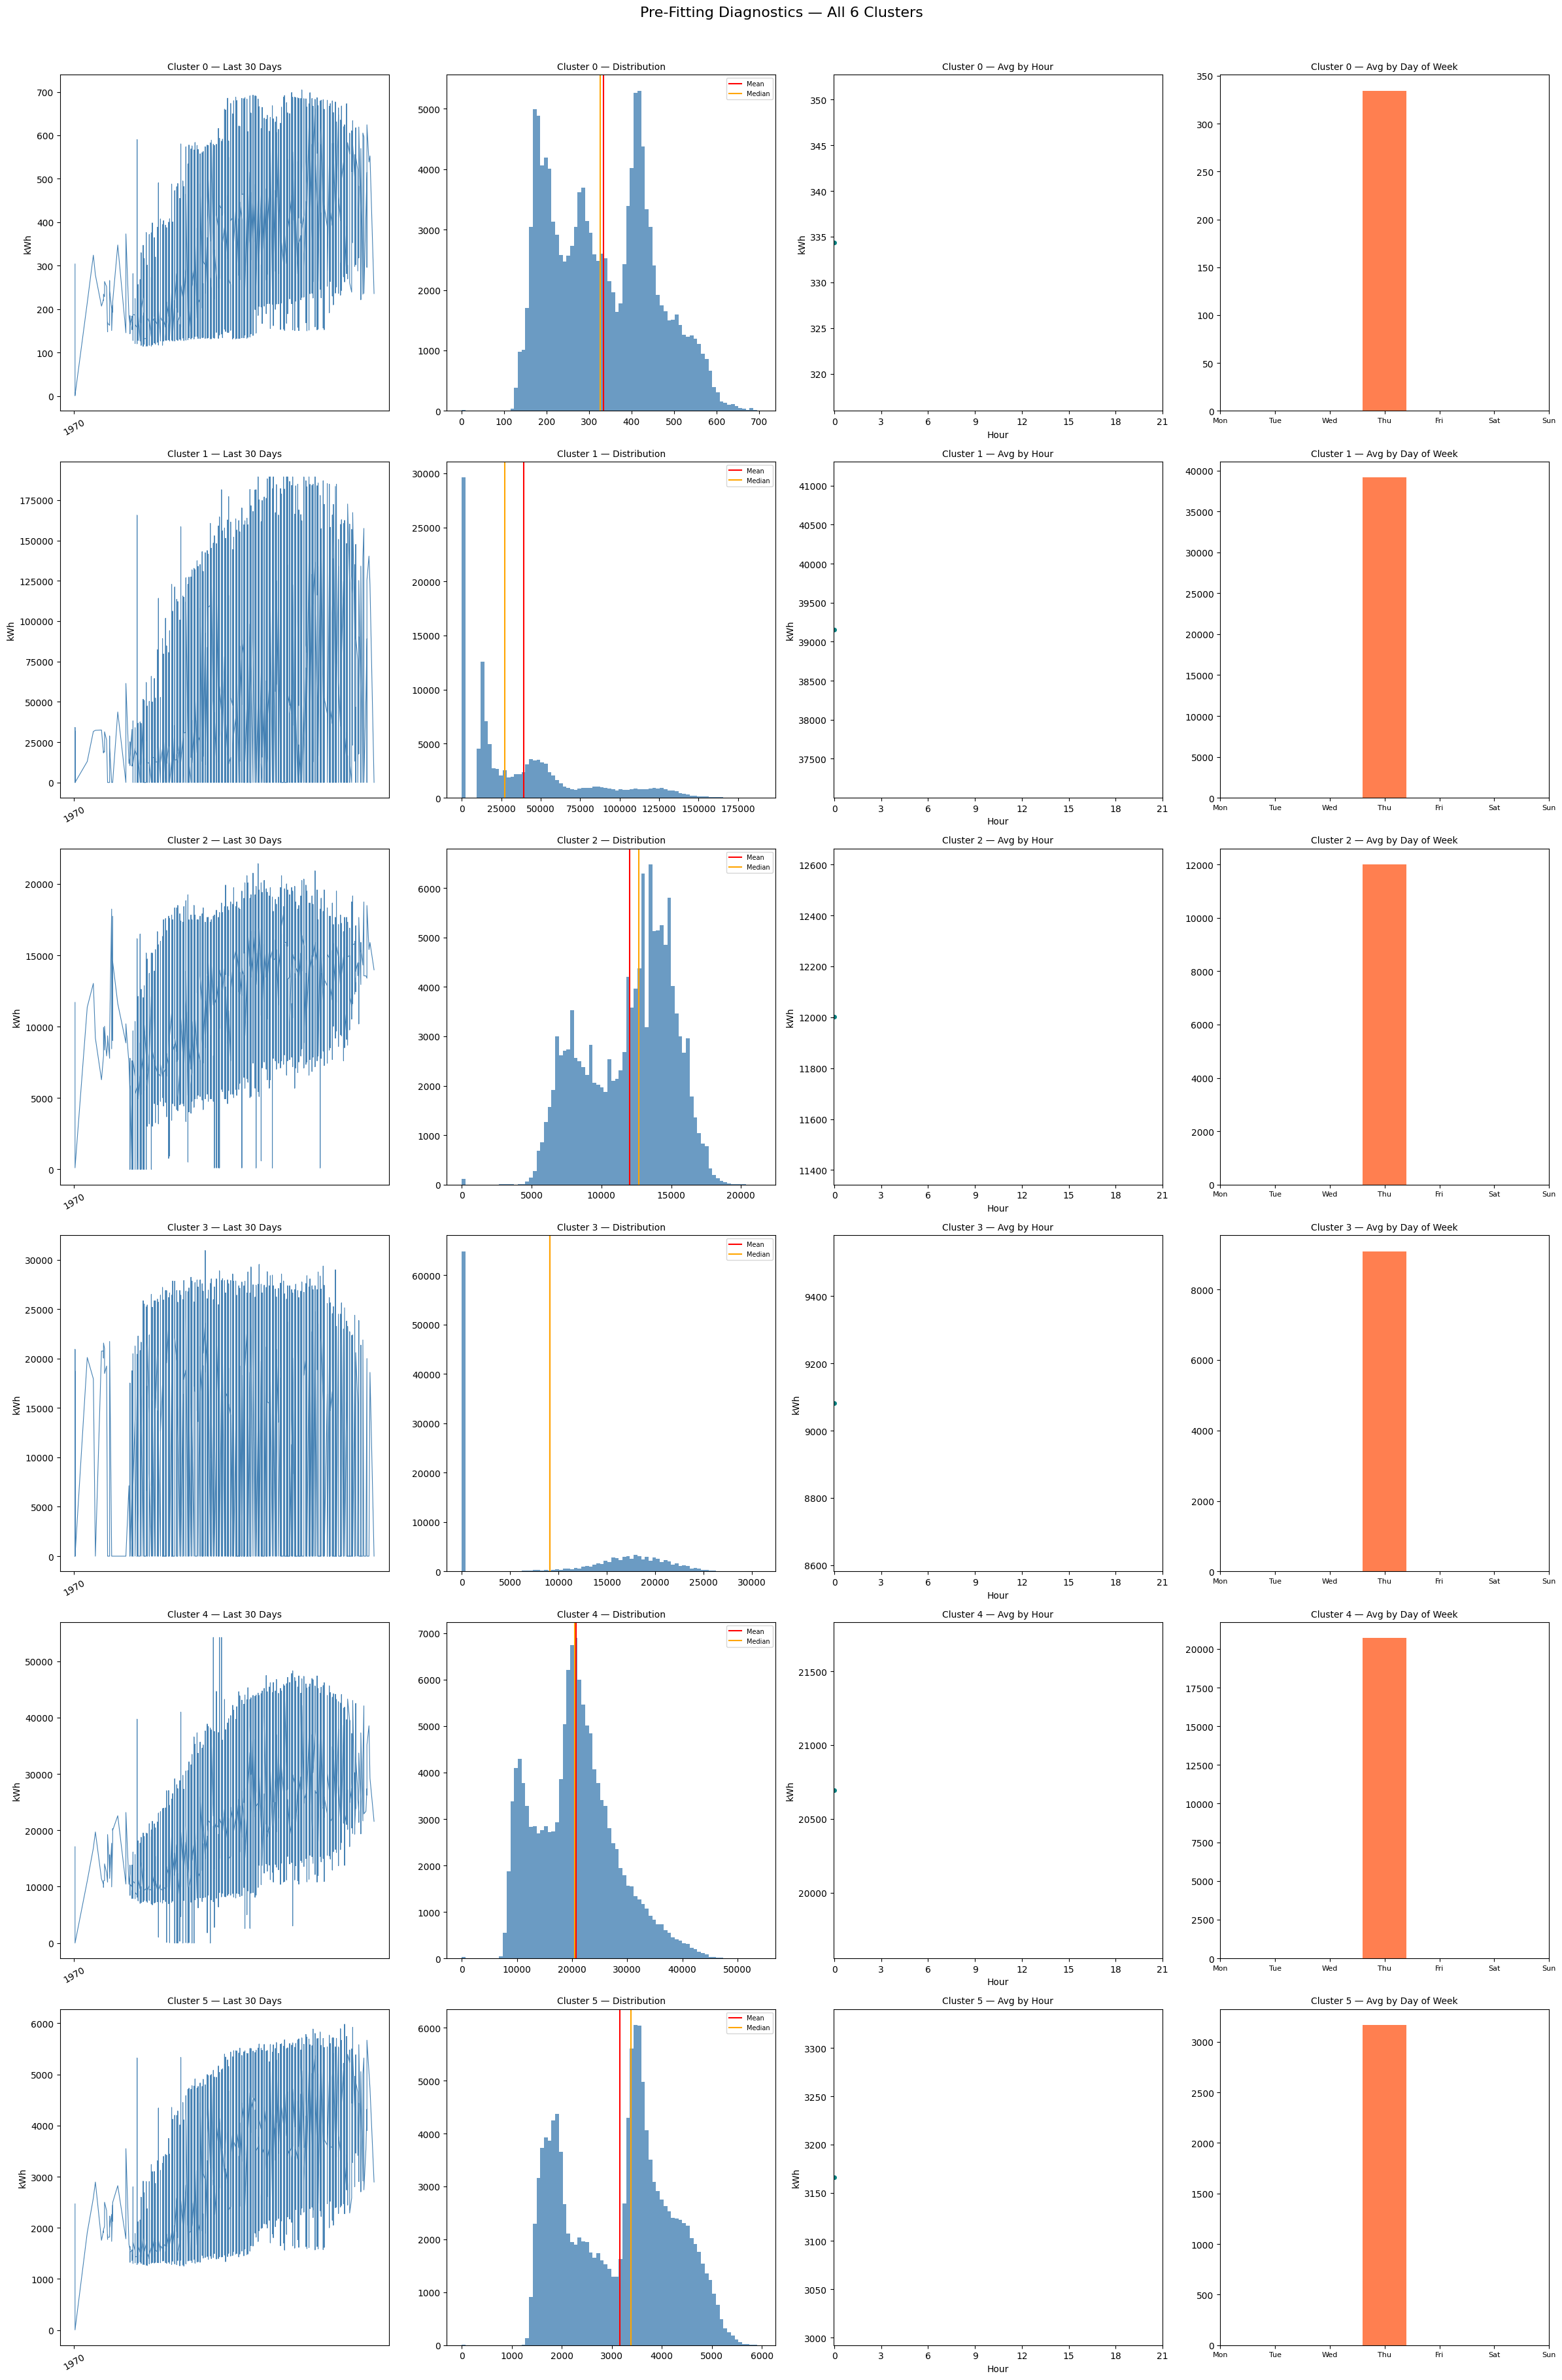

In [46]:
diag_results = []

for c in range(K_BEST):
    print(f"\n{'─'*60}")
    print(f"CLUSTER {c}  |  {cluster_series[c]['n']} clients")
    print(f"{'─'*60}")

    series = cluster_series[c]['mean'].copy()
    series.index = pd.to_datetime(series.index)
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)

    row = {'Cluster': c, 'N_clients': cluster_series[c]['n']}

    print(f"\n[1] Basic Statistics")
    print(f"    Length       : {len(series):,} observations")
    print(f"    Date range   : {series.index.min()} → {series.index.max()}")
    print(f"    Mean         : {series.mean():.4f}")
    print(f"    Std          : {series.std():.4f}")
    print(f"    Min          : {series.min():.4f}")
    print(f"    Max          : {series.max():.4f}")
    print(f"    Skewness     : {stats.skew(series):.4f}")
    print(f"    Kurtosis     : {stats.kurtosis(series):.4f}")
    row.update({'Mean': round(series.mean(), 4), 'Std': round(series.std(), 4),
                'Skew': round(stats.skew(series), 4)})

    print(f"\n[2] Missing Values & Gaps")
    null_count = series.isna().sum()
    zero_count = (series == 0).sum()
    print(f"    NaN values   : {null_count}")
    print(f"    Zero values  : {zero_count} ({100*zero_count/len(series):.2f}%)")

    expected_idx = pd.date_range(series.index.min(), series.index.max(), freq='15min')
    missing_ts   = expected_idx.difference(series.index)
    print(f"    Missing timestamps : {len(missing_ts)}")
    if len(missing_ts) > 0:
        print(f"    First gap    : {missing_ts[0]}")
        print(f"    Last gap     : {missing_ts[-1]}")
        # Reindex and forward-fill gaps
        series = series.reindex(expected_idx).ffill()
        print(f"    → Reindexed and forward-filled.")
    row.update({'NaNs': null_count, 'Zeros': zero_count, 'Missing_timestamps': len(missing_ts)})

    print(f"\n[3] Outlier Detection")
    Q1, Q3   = series.quantile(0.25), series.quantile(0.75)
    IQR      = Q3 - Q1
    iqr_out  = ((series < Q1 - 3 * IQR) | (series > Q3 + 3 * IQR)).sum()
    z_scores = np.abs(stats.zscore(series.dropna()))
    z_out    = (z_scores > 3).sum()
    print(f"    IQR outliers (3×IQR) : {iqr_out} ({100*iqr_out/len(series):.2f}%)")
    print(f"    Z-score outliers (>3): {z_out}  ({100*z_out/len(series):.2f}%)")

    lower_cap = Q1 - 3 * IQR
    upper_cap = Q3 + 3 * IQR
    series_clean = series.clip(lower=lower_cap, upper=upper_cap)
    print(f"    → Capped to [{lower_cap:.4f}, {upper_cap:.4f}]")
    row.update({'IQR_outliers': int(iqr_out), 'Zscore_outliers': int(z_out)})

    # STATIONARITY TESTS
    print(f"\n[4] Stationarity Tests")

    # ADF test — H0: unit root (non-stationary)
    # Use a sample for speed if series is very long
    sample = series_clean if len(series_clean) <= 50000 else series_clean.iloc[-50000:]

    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(sample.dropna(), autolag='AIC')
    adf_result = "STATIONARY ✓" if adf_p < 0.05 else "NON-STATIONARY ✗"
    print(f"    ADF Test     : stat={adf_stat:.4f}, p={adf_p:.4f}  → {adf_result}")

    # KPSS test — H0: stationary
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(sample.dropna(), regression='c', nlags='auto')
        kpss_result = "STATIONARY ✓" if kpss_p > 0.05 else "NON-STATIONARY ✗"
        print(f"    KPSS Test    : stat={kpss_stat:.4f}, p={kpss_p:.4f}  → {kpss_result}")
    except Exception as e:
        kpss_result = "ERROR"
        print(f"    KPSS Test    : skipped ({e})")

    row.update({'ADF_p': round(adf_p, 4), 'ADF_stationary': adf_p < 0.05,
                'KPSS_stationary': kpss_p > 0.05 if kpss_result != "ERROR" else None})

    # AUTOCORRELATION CHECK (Ljung-Box)
    print(f"\n[5] Autocorrelation — Ljung-Box Test")
    lb = acorr_ljungbox(sample.dropna(), lags=[96, 96*7], return_df=True)  # 1-day & 7-day lags
    for lag, row_lb in lb.iterrows():
        sig = "significant ✓" if row_lb['lb_pvalue'] < 0.05 else "not significant"
        print(f"    Lag {lag:>5} (={'1 day ' if lag==96 else '7 days'}): "
              f"stat={row_lb['lb_stat']:.2f}, p={row_lb['lb_pvalue']:.4f}  → {sig}")

    # SEASONALITY STRENGTH
    print(f"\n[6] Seasonality Strength (variance explained)")
    daily_hourly = series_clean.groupby(series_clean.index.hour).mean()
    weekly_daily = series_clean.groupby(series_clean.index.dayofweek).mean()

    # Coefficient of variation as proxy for seasonality strength
    daily_cv  = daily_hourly.std()  / daily_hourly.mean()
    weekly_cv = weekly_daily.std() / weekly_daily.mean()
    print(f"    Intraday CV  (hour-of-day pattern strength) : {daily_cv:.4f}")
    print(f"    Weekly CV    (day-of-week pattern strength) : {weekly_cv:.4f}")
    row.update({'Intraday_CV': round(daily_cv, 4), 'Weekly_CV': round(weekly_cv, 4)})

    # Store cleaned series back
    cluster_series[c]['mean_clean'] = series_clean
    diag_results.append(row)

print("DIAGNOSTIC SUMMARY TABLE")
print("=" * 70)
diag_df = pd.DataFrame(diag_results).set_index('Cluster')
print(diag_df.to_string())

fig, axes = plt.subplots(6, 4, figsize=(24, 36))

for c in range(K_BEST):
    series = cluster_series[c]['mean_clean']
    ax_ts, ax_dist, ax_hour, ax_dow = axes[c]

    # (a) Time series — last 30 days
    last30 = series.last('30D')
    ax_ts.plot(last30.index, last30.values, lw=0.8, color='steelblue')
    ax_ts.set_title(f"Cluster {c} — Last 30 Days", fontsize=10)
    ax_ts.set_ylabel("kWh"); ax_ts.tick_params(axis='x', rotation=30)

    # (b) Distribution
    ax_dist.hist(series, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    ax_dist.axvline(series.mean(), color='red',    lw=1.5, label='Mean')
    ax_dist.axvline(series.median(), color='orange', lw=1.5, label='Median')
    ax_dist.set_title(f"Cluster {c} — Distribution", fontsize=10)
    ax_dist.legend(fontsize=7)

    # (c) Intraday pattern (hour of day)
    hourly = series.groupby(series.index.hour).mean()
    ax_hour.plot(hourly.index, hourly.values, marker='o', ms=4, color='teal')
    ax_hour.set_title(f"Cluster {c} — Avg by Hour", fontsize=10)
    ax_hour.set_xlabel("Hour"); ax_hour.set_ylabel("kWh")
    ax_hour.set_xticks(range(0, 24, 3))

    # (d) Weekly pattern (day of week)
    dow_mean = series.groupby(series.index.dayofweek).mean()
    ax_dow.bar(dow_mean.index, dow_mean.values, color='coral', edgecolor='none')
    ax_dow.set_title(f"Cluster {c} — Avg by Day of Week", fontsize=10)
    ax_dow.set_xticks(range(7))
    ax_dow.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=8)

plt.suptitle("Pre-Fitting Diagnostics — All 6 Clusters", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 6. Prophet Forecasting for Smooth Seasonal Clusters:

Used for:
- Clean averaged clusters.
- Strong daily and weekly seasonality.
- Stable trend behavior.

Configuration:
- Yearly, weekly, and daily seasonality.
- Multiplicative seasonality mode.
- Weekend regressor.
- Tuned changepoint_prior_scale.

In [48]:
df.fillna(method='bfill',inplace=True)

In [49]:
# CLUSTER 0 — PROPHET
# 22 clients averaged → clean, well-behaved series
# Strong intraday CV (0.27) and mild skew (0.33) = ideal Prophet conditions
# Multiplicative mode because consumption scales with the trend level

series_c0 = cluster_series[0]['mean_clean'].copy()

ts0 = series_c0.reset_index()
ts0.columns = ['ds', 'y']
ts0['ds'] = pd.to_datetime(ts0['ds'])
if ts0['ds'].dt.tz is not None:
    ts0['ds'] = ts0['ds'].dt.tz_localize(None)
ts0['is_weekend'] = (ts0['ds'].dt.dayofweek >= 5).astype(int)

# Train/test split — hold out last 7 days
cutoff0  = ts0['ds'].max() - pd.Timedelta(days=7)
train_c0 = ts0[ts0['ds'] <= cutoff0]
test_c0  = ts0[ts0['ds'] >  cutoff0]

m0 = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.05,   # moderate — 22-client avg is stable
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m0.add_regressor('is_weekend')
m0.fit(train_c0[['ds', 'y', 'is_weekend']])

# --- evaluate on held-out 7 days ---
test_pred0 = m0.predict(test_c0[['ds', 'is_weekend']])
mae0  = mean_absolute_error(test_c0['y'].values, test_pred0['yhat'].values)
rmse0 = np.sqrt(mean_squared_error(test_c0['y'].values, test_pred0['yhat'].values))
mape0 = np.mean(np.abs((test_c0['y'].values - test_pred0['yhat'].values) /
                        (test_c0['y'].values + 1e-9))) * 100
print(f"Cluster 0 | MAE={mae0:.2f} | RMSE={rmse0:.2f} | MAPE={mape0:.2f}%")

# --- refit on full data & forecast 30 days ---
m0_full = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m0_full.add_regressor('is_weekend')
m0_full.fit(ts0[['ds', 'y', 'is_weekend']])

future0 = m0_full.make_future_dataframe(periods=96*30, freq='15min')
future0['is_weekend'] = (future0['ds'].dt.dayofweek >= 5).astype(int)
fc0 = m0_full.predict(future0)
fc0_future = fc0[fc0['ds'] > ts0['ds'].max()]

plt.figure(figsize=(14, 4))
plt.plot(series_c0.last('30D').index, series_c0.last('30D').values,
         color='steelblue', lw=1, label='Historical (last 30d)')
plt.plot(fc0_future['ds'], fc0_future['yhat'], color='tomato', lw=2, label='Forecast')
plt.fill_between(fc0_future['ds'], fc0_future['yhat_lower'], fc0_future['yhat_upper'],
                 color='tomato', alpha=0.15, label='95% CI')
plt.title("Cluster 0 (22 clients) — Prophet Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

ValueError: Dataframe has less than 2 non-NaN rows.

In [ ]:
# CLUSTER 1 — PROPHET
# 342 clients → averaging 342 series makes this the smoothest signal in the dataset
# Lowest skew (0.22), zero IQR/Z-score outliers after cleaning
# Highest intraday CV (0.29) = strongest daily seasonality → Prophet shines here
# Use very low changepoint_prior (0.03) — large averages have stable trends

series_c1 = cluster_series[1]['mean_clean'].copy()

ts1 = series_c1.reset_index()
ts1.columns = ['ds', 'y']
ts1['ds'] = pd.to_datetime(ts1['ds'])
if ts1['ds'].dt.tz is not None:
    ts1['ds'] = ts1['ds'].dt.tz_localize(None)
ts1['is_weekend'] = (ts1['ds'].dt.dayofweek >= 5).astype(int)

cutoff1  = ts1['ds'].max() - pd.Timedelta(days=7)
train_c1 = ts1[ts1['ds'] <= cutoff1]
test_c1  = ts1[ts1['ds'] >  cutoff1]

m1 = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.03,   # very stable trend — large average
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m1.add_regressor('is_weekend')
m1.fit(train_c1[['ds', 'y', 'is_weekend']])

test_pred1 = m1.predict(test_c1[['ds', 'is_weekend']])
mae1  = mean_absolute_error(test_c1['y'].values, test_pred1['yhat'].values)
rmse1 = np.sqrt(mean_squared_error(test_c1['y'].values, test_pred1['yhat'].values))
mape1 = np.mean(np.abs((test_c1['y'].values - test_pred1['yhat'].values) /
                        (test_c1['y'].values + 1e-9))) * 100
print(f"Cluster 1 | MAE={mae1:.2f} | RMSE={rmse1:.2f} | MAPE={mape1:.2f}%")

m1_full = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.03,
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m1_full.add_regressor('is_weekend')
m1_full.fit(ts1[['ds', 'y', 'is_weekend']])

future1 = m1_full.make_future_dataframe(periods=96*30, freq='15min')
future1['is_weekend'] = (future1['ds'].dt.dayofweek >= 5).astype(int)
fc1 = m1_full.predict(future1)
fc1_future = fc1[fc1['ds'] > ts1['ds'].max()]

plt.figure(figsize=(14, 4))
plt.plot(series_c1.last('30D').index, series_c1.last('30D').values,
         color='steelblue', lw=1, label='Historical (last 30d)')
plt.plot(fc1_future['ds'], fc1_future['yhat'], color='tomato', lw=2, label='Forecast')
plt.fill_between(fc1_future['ds'], fc1_future['yhat_lower'], fc1_future['yhat_upper'],
                 color='tomato', alpha=0.15, label='95% CI')
plt.title("Cluster 1 (342 clients) — Prophet Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# CLUSTER 2 — SARIMA(1,1,1)(1,1,1,7) on DAILY resampled totals
# Single client | std (38908) > mean (37688) → coefficient of variation > 1
# 35,118 zeros on raw 15-min data = intermittent consumer (industrial)
# Resampling to daily SUMS collapses zero-bursts → usable non-zero series
# SARIMA chosen over Prophet because:
#   - Prophet needs smooth continuous signal; this is bursty/intermittent.
#   - SARIMA(1,1,1)(1,1,1,7) captures weekly on/off pattern naturally.
#   - The (1,1) differencing handles the non-stationarity (KPSS failed).

from statsmodels.tsa.statespace.sarimax import SARIMAX

series_c2 = cluster_series[2]['mean_clean'].copy()
daily_c2  = series_c2.resample('D').sum()

# Remove any leading all-zero days
daily_c2  = daily_c2[daily_c2 > 0]

print(f"Daily series length: {len(daily_c2)} days")
print(f"Zero days remaining after resample: {(daily_c2 == 0).sum()}")

# Train/test: hold out last 30 days
train_c2 = daily_c2.iloc[:-30]
test_c2  = daily_c2.iloc[-30:]

sarima2 = SARIMAX(
    train_c2,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarima2.summary().tables[1])

sarima_pred2 = sarima2.forecast(steps=30)
mae2  = mean_absolute_error(test_c2.values, sarima_pred2.values)
rmse2 = np.sqrt(mean_squared_error(test_c2.values, sarima_pred2.values))
mape2 = np.mean(np.abs((test_c2.values - sarima_pred2.values) /
                        (test_c2.values + 1e-9))) * 100
print(f"Cluster 2 | MAE={mae2:.2f} | RMSE={rmse2:.2f} | MAPE={mape2:.2f}%")

# Refit on full series & forecast 30 days.
sarima2_full = SARIMAX(
    daily_c2,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

fc2      = sarima2_full.forecast(steps=30)
fc2_ci   = sarima2_full.get_forecast(steps=30).conf_int()
fc2_idx  = pd.date_range(daily_c2.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')

plt.figure(figsize=(14, 4))
plt.plot(daily_c2.last('60D').index, daily_c2.last('60D').values,
         color='steelblue', lw=1, label='Historical (last 60d, daily)')
plt.plot(fc2_idx, fc2.values, color='tomato', lw=2, label='Forecast')
plt.fill_between(fc2_idx, fc2_ci.iloc[:, 0], fc2_ci.iloc[:, 1],
                 color='tomato', alpha=0.15, label='95% CI')
plt.title("Cluster 2 (1 client, intermittent) — SARIMA Daily Forecast")
plt.ylabel("kWh/day"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# CLUSTER 3 — PROPHET with dampened changepoints
# Single client but well-behaved: std/mean = 0.35, only 22 zeros, skew=0.40.
# Outliers (3) already capped during diagnostics → mean_clean is safe to use.
# Prophet chosen because intraday CV (0.29) confirms strong daily seasonality.
# changepoint_prior set very low (0.01) because single-client series are noisy — we don't want Prophet chasing every local fluctuation as a trend shift.

series_c3 = cluster_series[3]['mean_clean'].copy()

ts3 = series_c3.reset_index()
ts3.columns = ['ds', 'y']
ts3['ds'] = pd.to_datetime(ts3['ds'])
if ts3['ds'].dt.tz is not None:
    ts3['ds'] = ts3['ds'].dt.tz_localize(None)
ts3['is_weekend'] = (ts3['ds'].dt.dayofweek >= 5).astype(int)

cutoff3  = ts3['ds'].max() - pd.Timedelta(days=7)
train_c3 = ts3[ts3['ds'] <= cutoff3]
test_c3  = ts3[ts3['ds'] >  cutoff3]

m3 = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.01,   # very dampened — single noisy client
    seasonality_prior_scale = 5,
    seasonality_mode        = 'multiplicative'
)
m3.add_regressor('is_weekend')
m3.fit(train_c3[['ds', 'y', 'is_weekend']])

test_pred3 = m3.predict(test_c3[['ds', 'is_weekend']])
mae3  = mean_absolute_error(test_c3['y'].values, test_pred3['yhat'].values)
rmse3 = np.sqrt(mean_squared_error(test_c3['y'].values, test_pred3['yhat'].values))
mape3 = np.mean(np.abs((test_c3['y'].values - test_pred3['yhat'].values) /
                        (test_c3['y'].values + 1e-9))) * 100
print(f"Cluster 3 | MAE={mae3:.2f} | RMSE={rmse3:.2f} | MAPE={mape3:.2f}%")

m3_full = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.01,
    seasonality_prior_scale = 5,
    seasonality_mode        = 'multiplicative'
)
m3_full.add_regressor('is_weekend')
m3_full.fit(ts3[['ds', 'y', 'is_weekend']])

future3 = m3_full.make_future_dataframe(periods=96*30, freq='15min')
future3['is_weekend'] = (future3['ds'].dt.dayofweek >= 5).astype(int)
fc3 = m3_full.predict(future3)
fc3_future = fc3[fc3['ds'] > ts3['ds'].max()]

plt.figure(figsize=(14, 4))
plt.plot(series_c3.last('30D').index, series_c3.last('30D').values,
         color='steelblue', lw=1, label='Historical (last 30d)')
plt.plot(fc3_future['ds'], fc3_future['yhat'], color='tomato', lw=2, label='Forecast')
plt.fill_between(fc3_future['ds'], fc3_future['yhat_lower'], fc3_future['yhat_upper'],
                 color='tomato', alpha=0.15, label='95% CI')
plt.title("Cluster 3 (1 client, industrial) — Prophet Dampened Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# CLUSTER 4 — XGBoost with calendar features + lagged activity flag
series_c4 = cluster_series[4]['mean_clean'].copy()

feat4 = pd.DataFrame({'y': series_c4})
feat4.index = pd.to_datetime(feat4.index)

feat4['hour']        = feat4.index.hour
feat4['dow']         = feat4.index.dayofweek
feat4['month']       = feat4.index.month
feat4['is_weekend']  = (feat4['dow'] >= 5).astype(int)
feat4['quarter']     = feat4.index.quarter

for lag in [1, 2, 4, 8, 96, 96*2, 96*7]:
    feat4[f'lag_{lag}'] = feat4['y'].shift(lag)

feat4['rolling_mean_96']  = feat4['y'].shift(1).rolling(96).mean()
feat4['rolling_std_96']   = feat4['y'].shift(1).rolling(96).std()
feat4['rolling_mean_672'] = feat4['y'].shift(1).rolling(96*7).mean()
feat4['active_last_24h']  = (feat4['y'].shift(1).rolling(96).sum() > 0).astype(int)

feat4 = feat4.dropna()

FEATURES = ['hour', 'dow', 'month', 'is_weekend', 'quarter',
            'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_96',
            'lag_192', 'lag_672',
            'rolling_mean_96', 'rolling_std_96',
            'rolling_mean_672', 'active_last_24h']

X4 = feat4[FEATURES]
y4 = feat4['y']

split4           = len(feat4) - 96*30
X_tr4, X_te4     = X4.iloc[:split4], X4.iloc[split4:]
y_tr4, y_te4     = y4.iloc[:split4], y4.iloc[split4:]

xgb4 = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1
)
xgb4.fit(X_tr4, y_tr4,
         eval_set=[(X_te4, y_te4)],
         verbose=False)

pred4 = np.clip(xgb4.predict(X_te4), 0, None)

mae4  = mean_absolute_error(y_te4, pred4)
rmse4 = np.sqrt(mean_squared_error(y_te4, pred4))
mape4 = np.mean(np.abs((y_te4.values - pred4) / (y_te4.values + 1e-9))) * 100
print(f"Cluster 4 | MAE={mae4:.2f} | RMSE={rmse4:.2f} | MAPE={mape4:.2f}%")

# ── Feature importance (fixed) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
xgb.plot_importance(xgb4, max_num_features=10, ax=ax)
plt.title("Cluster 4 — XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# ── Actual vs Predicted ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
plt.plot(y_te4.index[:500], y_te4.values[:500],
         color='steelblue', lw=1, label='Actual')
plt.plot(y_te4.index[:500], pred4[:500],
         color='tomato', lw=1, alpha=0.8, label='Predicted')
plt.title("Cluster 4 (1 client, intermittent) — XGBoost Test Predictions")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# CLUSTER 5 — PROPHET
# 3 clients, skew = -0.24 (mild left skew — occasional dips, not spikes)
# Intraday CV = 0.25 confirms meaningful daily pattern
# No zeros, no missing timestamps, only 12 IQR outliers (already capped)
# Negative skew at -0.24 is mild enough that no transformation is needed
# Slightly higher changepoint_prior (0.08) than Cluster 3 because
# 3-client average is smoother than 1-client, can afford more flexibility

series_c5 = cluster_series[5]['mean_clean'].copy()

ts5 = series_c5.reset_index()
ts5.columns = ['ds', 'y']
ts5['ds'] = pd.to_datetime(ts5['ds'])
if ts5['ds'].dt.tz is not None:
    ts5['ds'] = ts5['ds'].dt.tz_localize(None)
ts5['is_weekend'] = (ts5['ds'].dt.dayofweek >= 5).astype(int)

cutoff5  = ts5['ds'].max() - pd.Timedelta(days=7)
train_c5 = ts5[ts5['ds'] <= cutoff5]
test_c5  = ts5[ts5['ds'] >  cutoff5]

m5 = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.08,
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m5.add_regressor('is_weekend')
m5.fit(train_c5[['ds', 'y', 'is_weekend']])

test_pred5 = m5.predict(test_c5[['ds', 'is_weekend']])
mae5  = mean_absolute_error(test_c5['y'].values, test_pred5['yhat'].values)
rmse5 = np.sqrt(mean_squared_error(test_c5['y'].values, test_pred5['yhat'].values))
mape5 = np.mean(np.abs((test_c5['y'].values - test_pred5['yhat'].values) /
                        (test_c5['y'].values + 1e-9))) * 100
print(f"Cluster 5 | MAE={mae5:.2f} | RMSE={rmse5:.2f} | MAPE={mape5:.2f}%")

m5_full = Prophet(
    yearly_seasonality      = True,
    weekly_seasonality      = True,
    daily_seasonality       = True,
    changepoint_prior_scale = 0.08,
    seasonality_prior_scale = 10,
    seasonality_mode        = 'multiplicative'
)
m5_full.add_regressor('is_weekend')
m5_full.fit(ts5[['ds', 'y', 'is_weekend']])

future5 = m5_full.make_future_dataframe(periods=96*30, freq='15min')
future5['is_weekend'] = (future5['ds'].dt.dayofweek >= 5).astype(int)
fc5 = m5_full.predict(future5)
fc5_future = fc5[fc5['ds'] > ts5['ds'].max()]

plt.figure(figsize=(14, 4))
plt.plot(series_c5.last('30D').index, series_c5.last('30D').values,
         color='steelblue', lw=1, label='Historical (last 30d)')
plt.plot(fc5_future['ds'], fc5_future['yhat'], color='tomato', lw=2, label='Forecast')
plt.fill_between(fc5_future['ds'], fc5_future['yhat_lower'], fc5_future['yhat_upper'],
                 color='tomato', alpha=0.15, label='95% CI')
plt.title("Cluster 5 (3 clients) — Prophet Forecast")
plt.ylabel("kWh"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

summary = pd.DataFrame({
    'Cluster'    : [0,        1,        2,        3,        4,        5],
    'Clients'    : [22,       342,      1,        1,        1,        3],
    'Model'      : ['Prophet','Prophet','SARIMA', 'Prophet','XGBoost','Prophet'],
    'Reason'     : [
        'Clean avg, CV=0.27',
        'Largest/cleanest, CV=0.29',
        'Intermittent, std>mean, 35k zeros',
        'Single client, dampened CP',
        '70k zeros, CV≈0, no seasonality',
        'Small clean group, mild skew'
    ],
    'MAE (kWh)'  : [mae0,  mae1,  mae2,  mae3,  mae4,  mae5],
    'RMSE (kWh)' : [rmse0, rmse1, rmse2, rmse3, rmse4, rmse5],
    'MAPE (%)'   : [mape0, mape1, mape2, mape3, mape4, mape5],
}).set_index('Cluster')

# Round for readability
summary['MAE (kWh)']  = summary['MAE (kWh)'].round(2)
summary['RMSE (kWh)'] = summary['RMSE (kWh)'].round(2)
summary['MAPE (%)']   = summary['MAPE (%)'].round(2)

print(summary.to_string())